In [1]:
!pip install pandas
!pip install matplotlib
!pip install nltk
!pip install NRCLex==3.0.0
!pip install textblob
!pip install vaderSentiment

### Part A: Corpus Construction

In [2]:
import pandas as pd

data = pd.read_csv("goemotions_raw_train_simplified.csv")

In [3]:
data.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1548381000,1
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1548084200,37
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1546427800,37
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1547965000,18
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1546668500,2


In [4]:
data.describe()

,created_utc,rater_id
count,2.112250e+05,211225.000000
mean,1.547659e+09,37.619742
std,7.696842e+05,23.070528
min,1.546301e+09,0.000000
25%,1.546993e+09,19.000000
50%,1.547664e+09,37.000000
75%,1.548320e+09,57.000000
max,1.548979e+09,81.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   text         211225 non-null  object
 1   id           211225 non-null  object
 2   author       211225 non-null  object
 3   subreddit    211225 non-null  object
 4   link_id      211225 non-null  object
 5   parent_id    211225 non-null  object
 6   created_utc  211225 non-null  int64 
 7   rater_id     211225 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 12.9+ MB


In [6]:
data.drop_duplicates(subset="id", inplace=True)

In [7]:
# corpus_data = data[data["subreddit"].str.contains("gunpolitics|progun|liberalgunowners")]
# corpus_data
target_subreddits = ["gunpolitics", "progun", "liberalgunowners"]
corpus_data = data[data["subreddit"].isin(target_subreddits)].copy()
corpus_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 352 entries, 146 to 185689
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         352 non-null    object
 1   id           352 non-null    object
 2   author       352 non-null    object
 3   subreddit    352 non-null    object
 4   link_id      352 non-null    object
 5   parent_id    352 non-null    object
 6   created_utc  352 non-null    int64 
 7   rater_id     352 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 24.8+ KB


In [8]:
corpus_data[corpus_data["subreddit"] == "gunpolitics"].info()
corpus_data[corpus_data["subreddit"] == "gunpolitics"].head()

<class 'pandas.core.frame.DataFrame'>
Index: 68 entries, 215 to 174902
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         68 non-null     object
 1   id           68 non-null     object
 2   author       68 non-null     object
 3   subreddit    68 non-null     object
 4   link_id      68 non-null     object
 5   parent_id    68 non-null     object
 6   created_utc  68 non-null     int64 
 7   rater_id     68 non-null     int64 
dtypes: int64(2), object(6)
memory usage: 4.8+ KB


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
215,Weird how the cops can pick and choose which l...,ef75ws9,The_Sad_Deku,gunpolitics,t3_akp27t,t3_akp27t,1548705300,26
1197,SAF is also in the list for Facebook. I trigge...,ed9kwvh,shikkie,gunpolitics,t3_acnfv1,t1_ed9jg2i,1546648700,5
1364,"I think it’s a bit more complicated than that,...",ef6xwp8,Slowroll900,gunpolitics,t3_akp27t,t1_ef6xbtl,1548700400,39
3156,See my post about Ohio above. Not as bad as yo...,eetcctg,jimhjim,gunpolitics,t3_aj2a74,t1_eescljs,1548297000,61
3784,"I wish, the brainwashed idiots here in Califor...",efd8e5q,TPBfan74,gunpolitics,t3_al9h43,t1_efbzpwy,1548864100,19


In [9]:
corpus_data[corpus_data["subreddit"] == "progun"].info()
corpus_data[corpus_data["subreddit"] == "progun"].head()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, 146 to 185689
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         128 non-null    object
 1   id           128 non-null    object
 2   author       128 non-null    object
 3   subreddit    128 non-null    object
 4   link_id      128 non-null    object
 5   parent_id    128 non-null    object
 6   created_utc  128 non-null    int64 
 7   rater_id     128 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 9.0+ KB


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
146,Lol. Build your own or make some tweaks to the...,eenji2u,Lepreco-Inc,progun,t3_aier3m,t1_eenapev,1548114200,6
361,Ignorance is strength.,edzaz6n,Squiddy_titties,progun,t3_afimpr,t1_edz4wf0,1547395100,12
445,I knew I didn't like this guy when the NPR com...,ee71ta7,ajt666,progun,t3_agkox5,t3_agkox5,1547649700,16
968,And in some aren't permitted outside the home ...,eenlie8,DammitDan,progun,t3_ai593r,t1_eelftvl,1548115700,6
1081,How so. What is the basis for your feeling of ...,eeugdp1,justbingitxxx,progun,t3_aj7nto,t1_eeufqlx,1548340900,18


In [10]:
corpus_data[corpus_data["subreddit"] == "liberalgunowners"].info()
corpus_data[corpus_data["subreddit"] == "liberalgunowners"].head()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 222 to 168438
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         156 non-null    object
 1   id           156 non-null    object
 2   author       156 non-null    object
 3   subreddit    156 non-null    object
 4   link_id      156 non-null    object
 5   parent_id    156 non-null    object
 6   created_utc  156 non-null    int64 
 7   rater_id     156 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 11.0+ KB


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
222,Or perhaps we should look at the bigger proble...,edwk47h,[deleted],liberalgunowners,t3_af29k8,t1_edv6ijs,1547313400,50
1339,There is clearly something really goddamned wr...,edekjf0,DMooseJ,liberalgunowners,t3_ad5toc,t1_edegg8e,1546800900,22
1481,"I loathe him too, but I couldn't even get on b...",ednmhrc,bagofwisdom,liberalgunowners,t3_ae9x2m,t1_ednmcdm,1547062300,50
1625,"But the poster, on the other hand...",ed5ljmp,jajajajaj,liberalgunowners,t3_ac2kqm,t1_ed5hjp1,1546529800,70
1913,Not bad at all.,edvct1g,2ChanceRescue,liberalgunowners,t3_actskz,t1_edd0re9,1547271000,36


### Part B: VADER Sentiment Analysis

In [11]:
corpus_data.insert(8, "vader_positive", 0.0)
corpus_data.insert(9, "vader_negative", 0.0)
corpus_data.insert(10, "vader_neutral", 0.0)
corpus_data.insert(11, "vader_compound", 0.0)
corpus_data.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,vader_positive,vader_negative,vader_neutral,vader_compound
146,Lol. Build your own or make some tweaks to the...,eenji2u,Lepreco-Inc,progun,t3_aier3m,t1_eenapev,1548114200,6,0.0,0.0,0.0,0.0
215,Weird how the cops can pick and choose which l...,ef75ws9,The_Sad_Deku,gunpolitics,t3_akp27t,t3_akp27t,1548705300,26,0.0,0.0,0.0,0.0
222,Or perhaps we should look at the bigger proble...,edwk47h,[deleted],liberalgunowners,t3_af29k8,t1_edv6ijs,1547313400,50,0.0,0.0,0.0,0.0
361,Ignorance is strength.,edzaz6n,Squiddy_titties,progun,t3_afimpr,t1_edz4wf0,1547395100,12,0.0,0.0,0.0,0.0
445,I knew I didn't like this guy when the NPR com...,ee71ta7,ajt666,progun,t3_agkox5,t3_agkox5,1547649700,16,0.0,0.0,0.0,0.0


In [12]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
for index, row in corpus_data.iterrows():
    vs = analyzer.polarity_scores(row["text"])
    corpus_data.loc[index, ["vader_positive"]] = vs["pos"]
    corpus_data.loc[index, ["vader_negative"]] = vs["neg"]
    corpus_data.loc[index, ["vader_neutral"]] = vs["neu"]
    corpus_data.loc[index, ["vader_compound"]] = vs["compound"]

In [13]:
corpus_data.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,vader_positive,vader_negative,vader_neutral,vader_compound
146,Lol. Build your own or make some tweaks to the...,eenji2u,Lepreco-Inc,progun,t3_aier3m,t1_eenapev,1548114200,6,0.219,0.000,0.781,0.4215
215,Weird how the cops can pick and choose which l...,ef75ws9,The_Sad_Deku,gunpolitics,t3_akp27t,t3_akp27t,1548705300,26,0.000,0.063,0.937,-0.0900
222,Or perhaps we should look at the bigger proble...,edwk47h,[deleted],liberalgunowners,t3_af29k8,t1_edv6ijs,1547313400,50,0.151,0.146,0.703,0.0258
361,Ignorance is strength.,edzaz6n,Squiddy_titties,progun,t3_afimpr,t1_edz4wf0,1547395100,12,0.478,0.373,0.149,0.1779
445,I knew I didn't like this guy when the NPR com...,ee71ta7,ajt666,progun,t3_agkox5,t3_agkox5,1547649700,16,0.166,0.083,0.751,0.4749


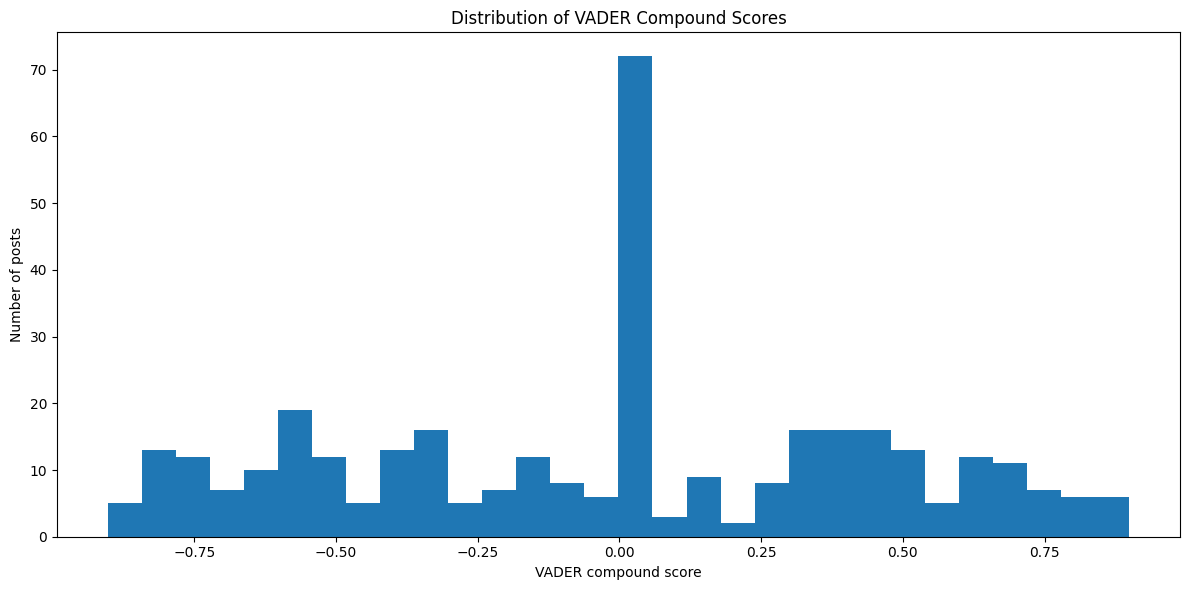

In [14]:
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(12, 6))
plt.hist(corpus_data["vader_compound"], bins=30)
plt.title("Distribution of VADER Compound Scores")
plt.xlabel("VADER compound score")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.savefig(
    output_dir / "goemotions_simplified_lab1_target_subreddits_vader_compound_histogram.png"
)

In [15]:
# plt.hist(corpus_data["vader_compound"], bins=30, edgecolor='black')
# corpus_data["vader_compound"].plot(kind='hist', bins=30, edgecolor='black')

### Part C: NRC Emotion Lexicon Analysis

In [16]:
cleaned_corpus_data = corpus_data.copy().drop(
    columns=["vader_positive", "vader_negative", "vader_neutral", "vader_compound"]
)

cleaned_corpus_data["text"] = (
    cleaned_corpus_data["text"]
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
)

In [17]:
cleaned_corpus_data.tail()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id
159343,used to be just bad on the 2nd now they are fo...,edzjono,GOA_AMD65,progun,t3_afk8sa,t1_edzb9is,1547400800,34
161004,when you glossed over name history to make a c...,efao1b1,RowdyPants,gunpolitics,t3_akzvn0,t1_efam9kw,1548795600,61
168438,i think theres a line between edgy and racist ...,edou5u6,d48reu,liberalgunowners,t3_aecsno,t1_edou1nn,1547095200,18
174902,and i wish i wasnt lumped in with new jersey,eet08tq,velocibadgery,gunpolitics,t3_aj2a74,t1_eeszyht,1548287700,23
185689,yes im an idiot checks out,efb0gx3,Randaethyr,progun,t3_al1uth,t1_efashlb,1548803000,57


Using lexicon from the resourses provided.

In [18]:
from pathlib import Path

def load_nrc_lexicon(path):
    lexicon_df = pd.read_csv(path, sep='\t', header=None, names=["word", "emotion", "value"], keep_default_na=False)
    return lexicon_df

file_path = Path("lab1_dictionary_sentiment.ipynb").resolve().parent
lexicon_df = load_nrc_lexicon(file_path / 'lab1_resources/nltk_data/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt')
pivoted = lexicon_df.pivot(index="word", columns="emotion", values="value")
pivoted.head()

emotion,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
word,,,,,,,,,,
aback,0,0,0,0,0,0,0,0,0,0
abacus,0,0,0,0,0,0,0,0,0,1
abandon,0,0,0,1,0,1,0,1,0,0
abandoned,1,0,0,1,0,1,0,1,0,0
abandonment,1,0,0,1,0,1,0,1,1,0


Getting the normalized NRC-scores with help function *get_emotions_with_lexicon*.

In [19]:
def get_emotions_with_lexicon(subreddit_name=None, comment=None):
    if subreddit_name:
        matrix = cleaned_corpus_data[cleaned_corpus_data["subreddit"] == subreddit_name]["text"].str.split()
        str_lexicon = [item for row in matrix for item in row]
    elif comment:
        str_lexicon = comment.split()
    else:
        matrix = cleaned_corpus_data["text"].str.split()
        str_lexicon = [item for row in matrix for item in row]
    matched_words = [word for word in str_lexicon if word in pivoted.index]
    lexicon_emotions = pivoted.loc[matched_words].sum() / len(str_lexicon)
    return lexicon_emotions

for name in ["gunpolitics", "progun", "liberalgunowners"]:
    subreddit_emotions = get_emotions_with_lexicon(subreddit_name=name)
    print(name, '-', subreddit_emotions)

gunpolitics - emotion
anger           0.032359
anticipation    0.015658
disgust         0.021921
fear            0.029228
joy             0.018789
negative        0.056367
positive        0.040710
sadness         0.024008
surprise        0.009395
trust           0.018789
dtype: float64
progun - emotion
anger           0.039813
anticipation    0.028689
disgust         0.018150
fear            0.044496
joy             0.022248
negative        0.056206
positive        0.052693
sadness         0.029274
surprise        0.016979
trust           0.039813
dtype: float64
liberalgunowners - emotion
anger           0.031925
anticipation    0.017371
disgust         0.019249
fear            0.032394
joy             0.013615
negative        0.057746
positive        0.039437
sadness         0.022066
surprise        0.008451
trust           0.022066
dtype: float64


Adding scores to a dataframe.

In [20]:
cleaned_corpus_data.insert(8, "nrc_anger", 0.0)
cleaned_corpus_data.insert(9, "nrc_anticipation", 0.0)
cleaned_corpus_data.insert(10, "nrc_disgust", 0.0)
cleaned_corpus_data.insert(11, "nrc_fear", 0.0)
cleaned_corpus_data.insert(11, "nrc_joy", 0.0)
cleaned_corpus_data.insert(11, "nrc_sadness", 0.0)
cleaned_corpus_data.insert(11, "nrc_surprise", 0.0)
cleaned_corpus_data.insert(11, "nrc_trust", 0.0)

In [21]:
for index, row in cleaned_corpus_data.iterrows():
    cleaned_corpus_data.loc[index, ["nrc_anger"]] = get_emotions_with_lexicon(comment=row["text"])["anger"]
    cleaned_corpus_data.loc[index, ["nrc_anticipation"]] = get_emotions_with_lexicon(comment=row["text"])["anticipation"]
    cleaned_corpus_data.loc[index, ["nrc_disgust"]] = get_emotions_with_lexicon(comment=row["text"])["disgust"]
    cleaned_corpus_data.loc[index, ["nrc_fear"]] = get_emotions_with_lexicon(comment=row["text"])["fear"]
    cleaned_corpus_data.loc[index, ["nrc_joy"]] = get_emotions_with_lexicon(comment=row["text"])["joy"]
    cleaned_corpus_data.loc[index, ["nrc_sadness"]] = get_emotions_with_lexicon(comment=row["text"])["sadness"]
    cleaned_corpus_data.loc[index, ["nrc_surprise"]] = get_emotions_with_lexicon(comment=row["text"])["surprise"]
    cleaned_corpus_data.loc[index, ["nrc_trust"]] = get_emotions_with_lexicon(comment=row["text"])["trust"]
# cleaned_corpus_data.loc[cleaned_corpus_data["nrc_anger"]>0]
cleaned_corpus_data.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,nrc_anger,nrc_anticipation,nrc_disgust,nrc_trust,nrc_surprise,nrc_sadness,nrc_joy,nrc_fear
146,lol build your own or make some tweaks to the ...,eenji2u,Lepreco-Inc,progun,t3_aier3m,t1_eenapev,1548114200,6,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
215,weird how the cops can pick and choose which l...,ef75ws9,The_Sad_Deku,gunpolitics,t3_akp27t,t3_akp27t,1548705300,26,0.047619,0.0,0.047619,0.000000,0.047619,0.000000,0.0,0.047619
222,or perhaps we should look at the bigger proble...,edwk47h,[deleted],liberalgunowners,t3_af29k8,t1_edv6ijs,1547313400,50,0.000000,0.0,0.000000,0.066667,0.000000,0.066667,0.0,0.066667
361,ignorance is strength,edzaz6n,Squiddy_titties,progun,t3_afimpr,t1_edz4wf0,1547395100,12,0.000000,0.0,0.000000,0.333333,0.000000,0.000000,0.0,0.000000
445,i knew i didnt like this guy when the npr comm...,ee71ta7,ajt666,progun,t3_agkox5,t3_agkox5,1547649700,16,0.047619,0.0,0.000000,0.095238,0.000000,0.000000,0.0,0.047619


### Part D: Visualization
A histogram of VADER compound sentiment scores can be found above.

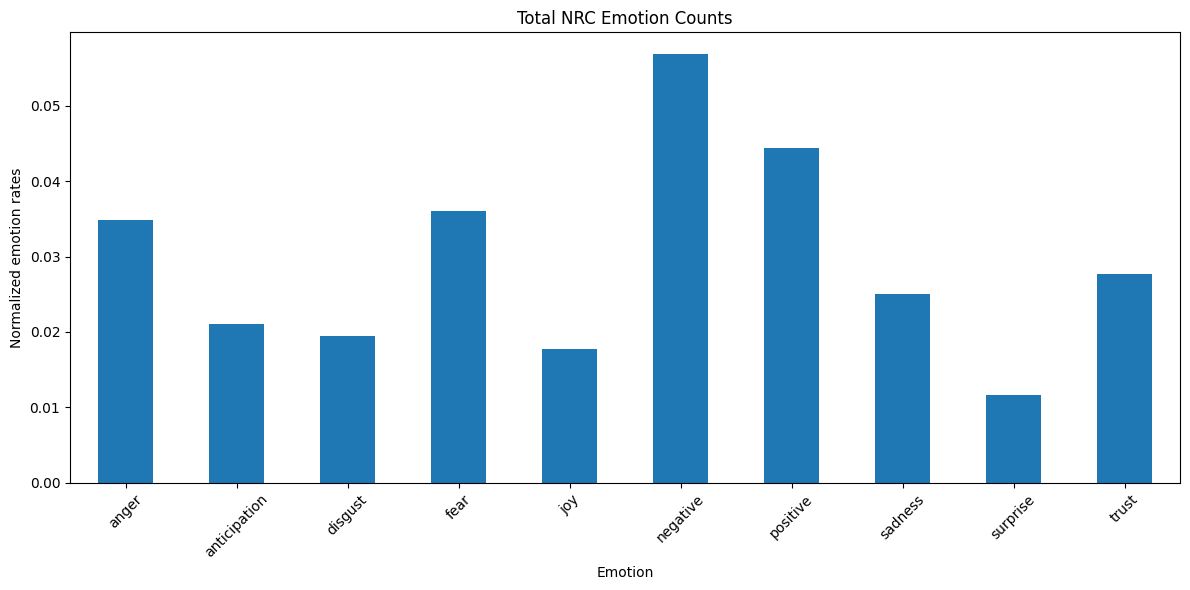

In [22]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

get_emotions_with_lexicon().plot(kind='bar',
        stacked=False,
        figsize=(12, 6),
        title='Corpus emotions')
plt.title("Total NRC Emotion Counts")
plt.xlabel("Emotion")
plt.ylabel("Normalized emotion rates")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    output_dir / "goemotions_simplified_lab1_target_subreddits_nrc_emotion_totals.png"
)

In [23]:
import matplotlib.pyplot as plt

# Combine into a DataFrame
df_nrc_by_subreddit = pd.DataFrame({"gunpolitics": get_emotions_with_lexicon("gunpolitics"), 
                   "progun": get_emotions_with_lexicon("progun"), "liberalgunowners": get_emotions_with_lexicon("liberalgunowners")})

In [24]:
df_nrc_by_subreddit = df_nrc_by_subreddit.transpose()
df_nrc_by_subreddit

emotion,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
gunpolitics,0.032359,0.015658,0.021921,0.029228,0.018789,0.056367,0.040710,0.024008,0.009395,0.018789
progun,0.039813,0.028689,0.018150,0.044496,0.022248,0.056206,0.052693,0.029274,0.016979,0.039813
liberalgunowners,0.031925,0.017371,0.019249,0.032394,0.013615,0.057746,0.039437,0.022066,0.008451,0.022066


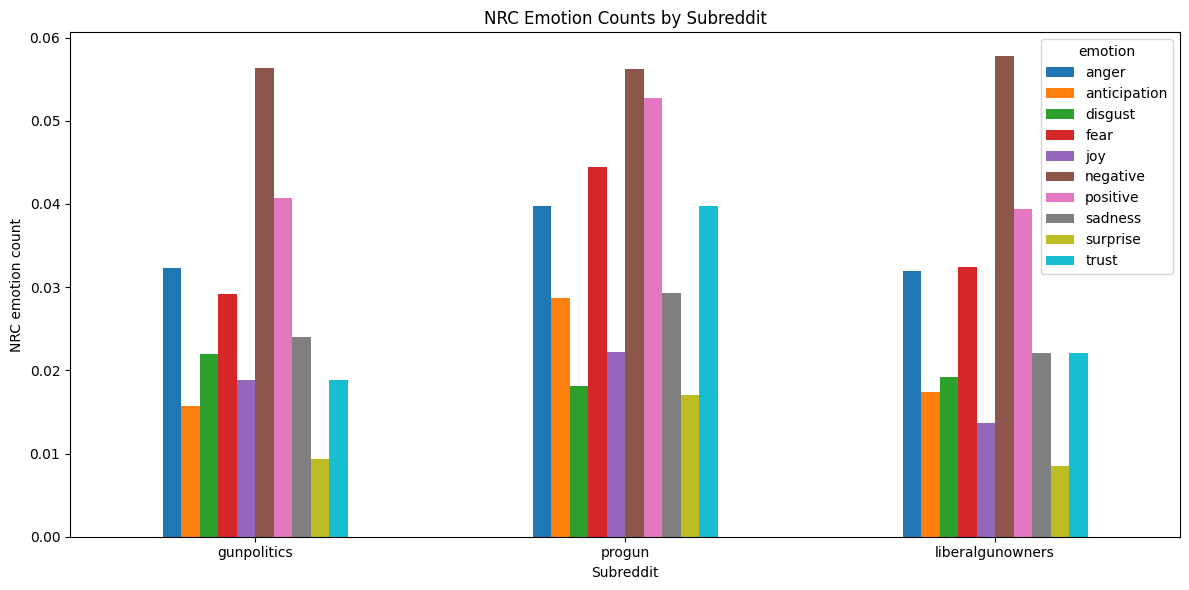

In [25]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

ax = df_nrc_by_subreddit.plot(
    kind="bar",
    figsize=(12, 6),
    title="NRC Emotion Counts by Subreddit"
)

ax.set_xlabel("Subreddit")
ax.set_ylabel("NRC emotion count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    output_dir / "goemotions_simplified_lab1_target_subreddits_nrc_by_subreddit.png"
)

### Output generation

Adding all the values together to generate the outputs.

In [26]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# goemotions_simplified_lab1_target_subreddits_sentiment.csv

emotions = list(pivoted.columns)

cleaned_corpus_data["token_count"] = cleaned_corpus_data["text"].str.split().str.len()

for emotion in emotions:
    cleaned_corpus_data[f"nrc_{emotion}_count"] = 0
    cleaned_corpus_data[f"nrc_{emotion}_rate"] = 0.0

for index, row in cleaned_corpus_data.iterrows():
    words = row["text"].split()
    matched_words = [word for word in words if word in pivoted.index]
    if matched_words:
        emotion_counts = pivoted.loc[matched_words].sum()
    else:
        emotion_counts = pd.Series(0, index=emotions)
    for emotion in emotions:
        cleaned_corpus_data.loc[index, f"nrc_{emotion}_count"] = emotion_counts[emotion]
        if row["token_count"] > 0:
            cleaned_corpus_data.loc[index, f"nrc_{emotion}_rate"] = (
                emotion_counts[emotion] / row["token_count"]
            )

corpus_data["token_count"] = cleaned_corpus_data["token_count"]

for emotion in emotions:
    corpus_data[f"nrc_{emotion}_count"] = cleaned_corpus_data[f"nrc_{emotion}_count"]
    corpus_data[f"nrc_{emotion}_rate"] = cleaned_corpus_data[f"nrc_{emotion}_rate"]

corpus_data.to_csv(
    output_dir / "goemotions_simplified_lab1_target_subreddits_sentiment.csv",
    index=False
)

# goemotions_simplified_lab1_target_subreddits_vader_summary.csv

vader_columns = [
    "vader_positive",
    "vader_negative",
    "vader_neutral",
    "vader_compound"
]

vader_summary = corpus_data[vader_columns].describe().T
vader_summary["median"] = corpus_data[vader_columns].median()

vader_summary.to_csv(
    output_dir / "goemotions_simplified_lab1_target_subreddits_vader_summary.csv"
)

# goemotions_simplified_lab1_target_subreddits_nrc_emotion_totals.csv

nrc_count_columns = [f"nrc_{emotion}_count" for emotion in emotions]

nrc_emotion_totals = corpus_data[nrc_count_columns].sum()
nrc_emotion_totals.index = [
    emotion.replace("nrc_", "").replace("_count", "")
    for emotion in nrc_emotion_totals.index
]

nrc_emotion_totals = nrc_emotion_totals.reset_index()
nrc_emotion_totals.columns = ["emotion", "total_count"]

nrc_emotion_totals.to_csv(
    output_dir / "goemotions_simplified_lab1_target_subreddits_nrc_emotion_totals.csv",
    index=False
)

# goemotions_simplified_lab1_target_subreddits_nrc_emotion_rates.csv

nrc_rate_columns = [f"nrc_{emotion}_rate" for emotion in emotions]

nrc_emotion_rates = corpus_data[nrc_rate_columns].mean()
nrc_emotion_rates.index = [
    emotion.replace("nrc_", "").replace("_rate", "")
    for emotion in nrc_emotion_rates.index
]

nrc_emotion_rates = nrc_emotion_rates.reset_index()
nrc_emotion_rates.columns = ["emotion", "mean_rate_per_token"]

nrc_emotion_rates.to_csv(
    output_dir / "goemotions_simplified_lab1_target_subreddits_nrc_emotion_rates.csv",
    index=False
)

# goemotions_simplified_lab1_target_subreddits_nrc_by_subreddit.csv

df_nrc_by_subreddit = corpus_data.groupby("subreddit")[nrc_count_columns].sum()

df_nrc_by_subreddit.columns = [
    column.replace("nrc_", "").replace("_count", "")
    for column in df_nrc_by_subreddit.columns
]

df_nrc_by_subreddit.to_csv(
    output_dir / "goemotions_simplified_lab1_target_subreddits_nrc_by_subreddit.csv"
)

### Aditional part

Experimenting with using NRCLex to get the scores (not normalized).

In [27]:
# Run once if TextBlob/NRClex corpora are missing:
# import nltk
# nltk.download("punkt")
# nltk.download("wordnet")
# nltk.download("averaged_perceptron_tagger")
# nltk.download("brown")

In [28]:
from nrclex import NRCLex

str_corpus = ' '.join(cleaned_corpus_data["text"])
text_object = NRCLex(str_corpus)

In [29]:
corpus_emotions = text_object.raw_emotion_scores
corpus_emotions

{'positive': 213,
 'disgust': 93,
 'negative': 274,
 'anger': 167,
 'fear': 174,
 'surprise': 56,
 'sadness': 121,
 'trust': 133,
 'anticipation': 101,
 'joy': 85}

In [30]:
def get_emotions(subreddit_name):
    str_subreddit = ' '.join(cleaned_corpus_data[cleaned_corpus_data["subreddit"] == subreddit_name]["text"])
    text_object = NRCLex(str_subreddit)
    subreddit_emotions = text_object.raw_emotion_scores
    return subreddit_emotions

for subreddit_name in ["gunpolitics", "progun", "liberalgunowners"]:
    subreddit_emotions = get_emotions(subreddit_name)
    print(subreddit_name, '-', subreddit_emotions)

gunpolitics - {'disgust': 21, 'negative': 54, 'positive': 39, 'anger': 31, 'fear': 28, 'surprise': 9, 'anticipation': 15, 'joy': 18, 'sadness': 23, 'trust': 18}
progun - {'positive': 90, 'negative': 97, 'trust': 68, 'anger': 68, 'fear': 77, 'anticipation': 49, 'disgust': 31, 'joy': 38, 'sadness': 51, 'surprise': 29}
liberalgunowners - {'fear': 69, 'negative': 123, 'sadness': 47, 'positive': 84, 'trust': 47, 'anger': 68, 'disgust': 41, 'anticipation': 37, 'surprise': 18, 'joy': 29}


In [31]:
bar_data = pd.DataFrame([get_emotions("gunpolitics")])
bar_data.loc[1] = get_emotions("progun").values()
bar_data.loc[2] = get_emotions("liberalgunowners").values()

In [32]:
bar_data.sort_index(axis=1, inplace=True)
bar_data.insert(0, "index", ["gunpolitics", "progun", "liberalgunowners"])
bar_data

,index,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
0,gunpolitics,31,15,21,28,18,54,39,23,9,18
1,progun,68,31,90,77,38,97,68,51,49,29
2,liberalgunowners,84,41,69,47,37,123,47,18,68,29


<Axes: title={'center': 'Grouped Bar Graph with dataframe'}, xlabel='index'>

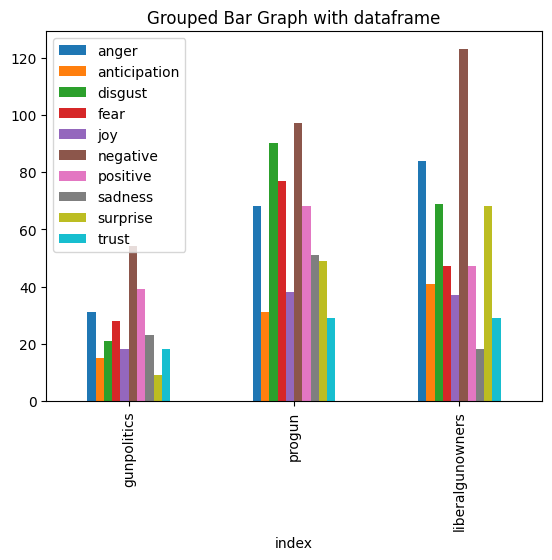

In [33]:
# plot grouped bar chart
bar_data.plot(x="index",
        kind='bar',
        stacked=False,
        title='Grouped Bar Graph with dataframe')